# OCR sobre fotos propias — YOLO26s-seg + EasyOCR + PaddleOCR

Alcance de este notebook, sin nada de más:

1. Cargar el checkpoint ya entrenado de **YOLO26s-seg** (`pesos/yolo26s_seg/mejor_map50.pt`) y correr inferencia sobre **tus 2 fotos propias** (no reentrena nada).
2. Recortar cada lomo detectado, enderezado a su eje.
3. Leer el texto de cada recorte con **EasyOCR** y **PaddleOCR**.
4. Armar una tabla comparando lo que leyó cada motor, lado a lado.

No incluye catálogo ni auditoría — eso se agrega después, una vez que se vea cuál de los dos motores lee mejor.


## 1) Instalación

In [23]:
import sys
print(sys.executable)

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\python.exe


In [16]:
%pip install -q opencv-python-headless numpy pandas matplotlib ultralytics easyocr paddleocr paddlepaddle rapidfuzz openpyxl


  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Acceso denegado: 'c:\\Users\\Usuario\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 2) Configuración

Poné tus 2 fotos en la carpeta `fotos_propias/`, en la raíz del repo (al lado de `dataset/` y `pesos/`).


In [4]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Localiza la raíz del repo (busca concepto/Plan.md) — misma lógica que los notebooks de los 4 modelos.
def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


RAIZ = raiz_del_repo()
CHECKPOINT_PATH = RAIZ / "pesos" / "yolo26s_seg" / "mejor_map50.pt"
FOTOS_DIR = RAIZ / "fotos_propias"
FOTOS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = RAIZ / "resultados_ocr"
CROPS_DIR = OUT_DIR / "recortes"
CROPS_DIR.mkdir(parents=True, exist_ok=True)

CATALOGO_XLSX = RAIZ / "catalogo" / "catalogo.xlsx"

print("Raíz del repo:", RAIZ)
print("Checkpoint:", CHECKPOINT_PATH, "| existe:", CHECKPOINT_PATH.exists())
print("Catálogo:", CATALOGO_XLSX, "| existe:", CATALOGO_XLSX.exists())

fotos = sorted(FOTOS_DIR.glob("*.jpg")) + sorted(FOTOS_DIR.glob("*.jpeg")) + sorted(FOTOS_DIR.glob("*.png"))
print(f"Fotos encontradas en {FOTOS_DIR}: {len(fotos)}")
for f in fotos:
    print(" -", f.name)
if not fotos:
    print("⚠️  Poné tus 2 fotos en esa carpeta (.jpg/.jpeg/.png) y volvé a correr esta celda.")


Raíz del repo: C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluacion
Checkpoint: C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluacion\pesos\yolo26s_seg\mejor_map50.pt | existe: True
Catálogo: C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluacion\catalogo\catalogo.xlsx | existe: True
Fotos encontradas en C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluacion\fotos_propias: 2
 - estante1.jpg
 - estante2.jpg


## 3) Detección y segmentación (YOLO26s-seg)

In [5]:
from ultralytics import YOLO

modelo = YOLO(str(CHECKPOINT_PATH))

CONF = 0.50
IOU = 0.40

resultados = modelo.predict(source=[str(f) for f in fotos], conf=CONF, iou=IOU, save=False, verbose=False)

total_lomos = sum(len(r.masks.xy) if r.masks is not None else 0 for r in resultados)
print(f"{len(resultados)} foto(s) procesadas, {total_lomos} lomos detectados en total")


WARNING NMS time limit 2.100s exceeded
2 foto(s) procesadas, 5 lomos detectados en total


## 4) Recorte de cada lomo (enderezado a su eje)

In [6]:
def crop_from_polygon(img, pts):
    """Recorta siguiendo el polígono predicho: rectángulo mínimo rotado + enderezado."""
    pts = np.array(pts, dtype=np.float32)
    (cx, cy), (rw, rh), angle = cv2.minAreaRect(pts)
    if rw < rh:
        rw, rh = rh, rw
        angle += 90

    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    h, w = img.shape[:2]
    rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    x1, y1 = int(cx - rw / 2), int(cy - rh / 2)
    x2, y2 = int(cx + rw / 2), int(cy + rh / 2)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    return rotated[y1:y2, x1:x2]


def preprocess_crop(crop, min_width=80):
    """Reescala (ancho mínimo) y mejora contraste (CLAHE) antes del OCR."""
    h, w = crop.shape[:2]
    if w < min_width and w > 0:
        scale = min_width / w
        crop = cv2.resize(crop, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


In [7]:
registros = []
for r in resultados:
    img_path = Path(r.path)
    img = cv2.imread(str(img_path))
    if r.masks is None:
        continue
    for i, poly in enumerate(r.masks.xy):
        crop = crop_from_polygon(img, poly)
        if crop.size == 0:
            continue
        crop = preprocess_crop(crop)
        crop_id = f"{img_path.stem}_{i:03d}"
        out_path = CROPS_DIR / f"{crop_id}.jpg"
        cv2.imwrite(str(out_path), crop)
        registros.append({"crop_id": crop_id, "imagen_origen": img_path.name, "crop_path": str(out_path)})

crops_df = pd.DataFrame(registros)
print(f"{len(crops_df)} recortes guardados en {CROPS_DIR}")
crops_df.head()


5 recortes guardados en C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluacion\resultados_ocr\recortes


,crop_id,imagen_origen,crop_path
0,estante1_000,estante1.jpg,C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluac...
1,estante1_001,estante1.jpg,C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluac...
2,estante1_002,estante1.jpg,C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluac...
3,estante1_003,estante1.jpg,C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluac...
4,estante1_004,estante1.jpg,C:\Users\Usuario\Desktop\DVxC-VcCII-TP-evaluac...


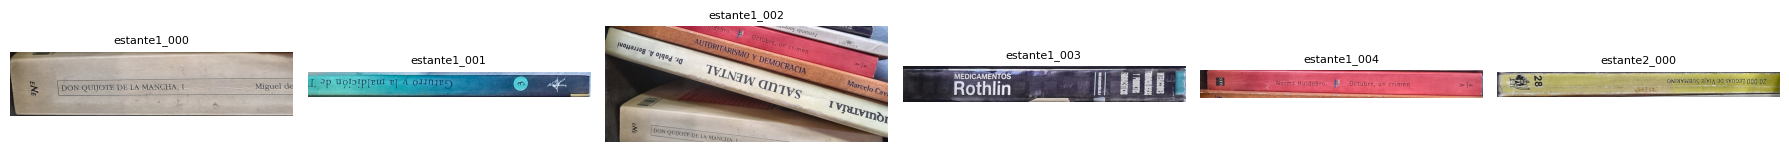

In [21]:
# Vista rápida de los recortes
if len(crops_df) > 0:
    n = min(6, len(crops_df))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
    for ax, (_, row) in zip(np.atleast_1d(axes), crops_df.head(n).iterrows()):
        img = cv2.cvtColor(cv2.imread(row["crop_path"]), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(row["crop_id"], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 5) OCR: EasyOCR y PaddleOCR

In [10]:
import time
import torch
import easyocr
from paddleocr import PaddleOCR

usar_gpu = torch.cuda.is_available()
print("GPU disponible:", usar_gpu)

easyocr_reader = easyocr.Reader(["es", "en"], gpu=usar_gpu)

# API de PaddleOCR 3.x: use_textline_orientation (antes use_angle_cls), sin show_log,
# y .predict() en vez de .ocr() (devuelve rec_texts/rec_scores, no listas anidadas).
paddleocr_reader = PaddleOCR(use_textline_orientation=True, lang="es")


def leer_easyocr(img_bgr):
    resultado = easyocr_reader.readtext(img_bgr)
    if not resultado:
        return "", 0.0
    texto = " ".join(r[1] for r in resultado)
    confianza = float(np.mean([r[2] for r in resultado]))
    return texto.strip(), confianza


def _obtener(res, clave):
    """PaddleOCR 3.x devuelve objetos tipo dict; soporta ambas formas de acceso."""
    try:
        return res[clave]
    except (TypeError, KeyError):
        return getattr(res, clave, None)


def leer_paddleocr(img_bgr):
    resultado = paddleocr_reader.predict(img_bgr)
    if not resultado:
        return "", 0.0
    res = resultado[0]
    textos = _obtener(res, "rec_texts") or []
    scores = _obtener(res, "rec_scores") or []
    if not textos:
        return "", 0.0
    texto = " ".join(textos)
    confianza = float(np.mean(scores)) if scores else 0.0
    return texto.strip(), confianza


def leer_mejor_rotacion(img_bgr, funcion_lectura, rotaciones=(0, 90, 270)):
    """Prueba 0°/90°/270° y se queda con la lectura de mayor confianza."""
    mejor_texto, mejor_conf, mejor_rot = "", -1.0, 0
    for rot in rotaciones:
        if rot == 0:
            rotada = img_bgr
        else:
            codigo = {90: cv2.ROTATE_90_CLOCKWISE, 270: cv2.ROTATE_90_COUNTERCLOCKWISE}[rot]
            rotada = cv2.rotate(img_bgr, codigo)
        texto, conf = funcion_lectura(rotada)
        if conf > mejor_conf:
            mejor_texto, mejor_conf, mejor_rot = texto, conf, rot
    return mejor_texto, mejor_conf, mejor_rot


Using CPU. Note: This module is much faster with a GPU.


GPU disponible: False


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Usuario\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Usuario\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Usuario\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Usuario\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory 

## 6) Comparar EasyOCR vs PaddleOCR, recorte por recorte

In [11]:
filas = []
for _, row in crops_df.iterrows():
    img = cv2.imread(row["crop_path"])

    t0 = time.time()
    texto_easy, conf_easy, rot_easy = leer_mejor_rotacion(img, leer_easyocr)
    latencia_easy = (time.time() - t0) * 1000

    t0 = time.time()
    texto_paddle, conf_paddle, rot_paddle = leer_mejor_rotacion(img, leer_paddleocr)
    latencia_paddle = (time.time() - t0) * 1000

    filas.append({
        "crop_id": row["crop_id"],
        "imagen_origen": row["imagen_origen"],
        "easyocr_texto": texto_easy,
        "easyocr_confianza": round(conf_easy, 3),
        "easyocr_latencia_ms": round(latencia_easy, 1),
        "paddleocr_texto": texto_paddle,
        "paddleocr_confianza": round(conf_paddle, 3),
        "paddleocr_latencia_ms": round(latencia_paddle, 1),
    })

comparativa_df = pd.DataFrame(filas)
comparativa_df.to_csv(OUT_DIR / "comparativa_ocr.csv", index=False)
comparativa_df


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at ..\paddle\fluid\framework\new_executor\instruction\onednn\onednn_instruction.cc:118)


In [ ]:
# Resumen: confianza y latencia promedio de cada motor (no reemplaza mirar la tabla de arriba a ojo)
resumen = pd.DataFrame({
    "motor": ["easyocr", "paddleocr"],
    "confianza_media": [comparativa_df["easyocr_confianza"].mean(), comparativa_df["paddleocr_confianza"].mean()],
    "latencia_media_ms": [comparativa_df["easyocr_latencia_ms"].mean(), comparativa_df["paddleocr_latencia_ms"].mean()],
})
resumen


## 7) Comparar contra el catálogo (`catalogo/catalogo.xlsx`)

Para cada recorte, busca el título más parecido dentro del catálogo (comparación difusa, tolera errores de OCR, mayúsculas, acentos) y marca si el texto leído **coincide** con algún libro real del catálogo o no — por separado para EasyOCR y para PaddleOCR. Esto no asume que el motor "sabe" qué libro es; solo mide si lo que leyó se parece lo suficiente a un título real como para identificarlo.


In [ ]:
from rapidfuzz import fuzz, process

UMBRAL_COINCIDENCIA = 85  # 0-100; subir si da falsos positivos, bajar si no encuentra coincidencias reales

catalogo_df = pd.read_excel(CATALOGO_XLSX)
catalogo_df.columns = [c.strip().lower() for c in catalogo_df.columns]  # por si vienen con mayúsculas/espacios
print(f"{len(catalogo_df)} libros en el catálogo")
catalogo_df.head()


In [ ]:
def mejor_match_catalogo(texto_leido, catalogo_df):
    texto_leido = str(texto_leido).strip()
    if catalogo_df.empty or not texto_leido:
        return None, None, 0
    titulos = catalogo_df["titulo"].astype(str).tolist()
    match, score, idx = process.extractOne(texto_leido, titulos, scorer=fuzz.token_sort_ratio)
    autor = catalogo_df.iloc[idx]["autor"] if "autor" in catalogo_df.columns else None
    return match, autor, score


filas_catalogo = []
for _, row in comparativa_df.iterrows():
    titulo_easy, autor_easy, score_easy = mejor_match_catalogo(row["easyocr_texto"], catalogo_df)
    titulo_paddle, autor_paddle, score_paddle = mejor_match_catalogo(row["paddleocr_texto"], catalogo_df)

    filas_catalogo.append({
        "crop_id": row["crop_id"],
        "imagen_origen": row["imagen_origen"],

        "easyocr_texto": row["easyocr_texto"],
        "easyocr_match_titulo": titulo_easy,
        "easyocr_match_score": score_easy,
        "easyocr_coincide": score_easy >= UMBRAL_COINCIDENCIA,

        "paddleocr_texto": row["paddleocr_texto"],
        "paddleocr_match_titulo": titulo_paddle,
        "paddleocr_match_score": score_paddle,
        "paddleocr_coincide": score_paddle >= UMBRAL_COINCIDENCIA,
    })

catalogo_match_df = pd.DataFrame(filas_catalogo)
catalogo_match_df.to_csv(OUT_DIR / "comparativa_catalogo.csv", index=False)
catalogo_match_df


In [ ]:
# Resumen: cuántos recortes coincidieron con el catálogo, por motor
resumen_catalogo = pd.DataFrame({
    "motor": ["easyocr", "paddleocr"],
    "coincidencias": [catalogo_match_df["easyocr_coincide"].sum(), catalogo_match_df["paddleocr_coincide"].sum()],
    "total_recortes": [len(catalogo_match_df)] * 2,
})
resumen_catalogo["porcentaje"] = (resumen_catalogo["coincidencias"] / resumen_catalogo["total_recortes"] * 100).round(1)
resumen_catalogo


In [ ]:
# Recortes donde un motor coincidió con el catálogo y el otro no — los casos más informativos para comparar
desacuerdos = catalogo_match_df[catalogo_match_df["easyocr_coincide"] != catalogo_match_df["paddleocr_coincide"]]
desacuerdos[["crop_id", "easyocr_texto", "easyocr_coincide", "paddleocr_texto", "paddleocr_coincide"]]
